In [1]:
import ast
import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# ===================== CONFIG (edit here only) =====================
ORGS = ["ESKAPE", "GAST", "INTRA", "RESP"]
DOMAIN = {"ESKAPE": "Bacterial", "GAST": "Bacterial", "INTRA": "Bacterial", "RESP": "Bacterial"}
# when viral groups are processed: DOMAIN["COV"] = DOMAIN["ENZA"] = "Viral"; add to ORGS
TYPES = ["linear", "conformational"]

STRUCTURE_BASE = Path("../structures")   # PDBs: STRUCTURE_BASE/{org}/{type}/{uniprot}.pdb -- SET TO YOUR ROOT
GT = Path("../iedb")                      # IEDB ground truth

GT_UNI = "uniprot_accession"
GT_START, GT_END = "start_pos", "end_pos"     # linear
GT_RESSET = "residue_set"                     # conformational
GT_ID = "iedb_id"

KMER_K = 5                # k-mer size for alignment-free similarity
NEAR_DUP_THRESHOLD = 0.9  # k-mer Jaccard at/above this = near-duplicate

# optional hooks (leave None to skip; set a path to enable)
RSA_SOURCE = None       # CSV with columns: uniprot, res_index, rsa
SPECIES_SOURCE = None   # CSV with columns: uniprot, species
MMSEQS_CLUSTERS = None  # MMseqs2 easy-cluster *_cluster.tsv (columns: representative, member)
# ==================================================================

THREE2ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C", "GLN": "Q", "GLU": "E",
    "GLY": "G", "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F",
    "PRO": "P", "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}


## 1. Load antigen structures (sequence, length, pLDDT)

One representative structure per antigen. Sequence and residue numbering come from the Cα atoms;
per-residue pLDDT is the Cα B-factor (AlphaFold stores confidence there).

In [2]:
def parse_structure(path):
    seq, plddt = {}, {}
    with open(path) as fh:
        for line in fh:
            if not line.startswith("ATOM") or line[12:16].strip() != "CA":
                continue
            ri = int(line[22:26])
            seq[ri] = THREE2ONE.get(line[17:20].strip(), "X")
            plddt[ri] = float(line[60:66])
    return seq, plddt

ant_rows, res_rows, seen = [], [], set()
for org in ORGS:
    for typ in TYPES:
        d = STRUCTURE_BASE / org / typ
        if not d.exists():
            continue
        for pdb in sorted(d.glob("*.pdb")):
            uni = pdb.stem
            if uni in seen:
                continue
            seen.add(uni)
            seq, plddt = parse_structure(pdb)
            if not seq:
                continue
            idx = sorted(seq)
            ant_rows.append({"uniprot": uni, "organism": org, "domain": DOMAIN.get(org, "Unknown"),
                             "length": len(idx), "sequence": "".join(seq[i] for i in idx),
                             "mean_plddt": float(np.mean([plddt[i] for i in idx]))})
            for i in idx:
                res_rows.append({"uniprot": uni, "organism": org, "res_index": i,
                                 "residue": seq[i], "plddt": plddt[i]})

antigens = pd.DataFrame(ant_rows)
residues = pd.DataFrame(res_rows)
print("antigens:", len(antigens), "| residues:", len(residues))
print(antigens.groupby(["domain", "organism"]).size())


antigens: 351 | residues: 152653
domain     organism
Bacterial  ESKAPE       64
           GAST         37
           INTRA        58
           RESP        192
dtype: int64


## 2. Epitope annotations (linear + conformational)

Per-residue labels and per-epitope records for each track, mapped onto the structures above.

In [3]:
def load_linear(org):
    p = GT / org / "linear" / "linear_ground_truth.csv"
    if not p.exists():
        return pd.DataFrame(), set()
    g = pd.read_csv(p)
    recs, resset = [], set()
    for i, r in g.iterrows():
        uni = str(r[GT_UNI]).strip(); s, e = int(r[GT_START]), int(r[GT_END])
        recs.append({"uniprot": uni, "iedb_id": r[GT_ID] if GT_ID in g.columns else i,
                     "length": e - s + 1, "track": "linear"})
        for x in range(s, e + 1):
            resset.add((uni, x))
    return pd.DataFrame(recs), resset

def load_conf(org):
    p = GT / org / "conformational" / "conformational_ground_truth.csv"
    if not p.exists():
        return pd.DataFrame(), set()
    g = pd.read_csv(p)
    recs, resset = [], set()
    for i, r in g.iterrows():
        uni = str(r[GT_UNI]).strip()
        try:
            residues_e = sorted(set(int(v) for v in ast.literal_eval(str(r[GT_RESSET]))))
        except Exception:
            residues_e = []
        if not residues_e:
            continue
        recs.append({"uniprot": uni, "iedb_id": r[GT_ID] if GT_ID in g.columns else i,
                     "length": len(residues_e), "track": "conformational"})
        for x in residues_e:
            resset.add((uni, x))
    return pd.DataFrame(recs), resset

epi_lin = pd.concat([load_linear(o)[0] for o in ORGS], ignore_index=True)
epi_con = pd.concat([load_conf(o)[0] for o in ORGS], ignore_index=True)
set_lin = set().union(*[load_linear(o)[1] for o in ORGS])
set_con = set().union(*[load_conf(o)[1] for o in ORGS])

residues["epi_linear"] = [(u, i) in set_lin for u, i in zip(residues.uniprot, residues.res_index)]
residues["epi_conf"] = [(u, i) in set_con for u, i in zip(residues.uniprot, residues.res_index)]
residues["epi_linear"] = residues["epi_linear"].astype(int)
residues["epi_conf"] = residues["epi_conf"].astype(int)
print("linear epitopes:", len(epi_lin), "| conformational epitopes:", len(epi_con))


linear epitopes: 2920 | conformational epitopes: 148


## 3. Dataset composition (Table 4.1)

In [4]:
comp = (antigens.groupby(["domain", "organism"])
        .agg(n_antigens=("uniprot", "nunique"),
             median_length=("length", "median"),
             median_plddt=("mean_plddt", "median")).reset_index())
print(comp.round(1).to_string(index=False))
print("\nTotal antigens:", antigens["uniprot"].nunique())

lin_cov = epi_lin["uniprot"].nunique()
con_cov = epi_con["uniprot"].nunique()
print(f"antigens with linear annotation: {lin_cov} | with conformational: {con_cov}")


   domain organism  n_antigens  median_length  median_plddt
Bacterial   ESKAPE          64          391.0          88.9
Bacterial     GAST          37          363.0          90.3
Bacterial    INTRA          58          324.5          80.0
Bacterial     RESP         192          372.0          87.5

Total antigens: 351
antigens with linear annotation: 345 | with conformational: 38


## 4. Tier 1 — sequence length

Length drives the micro-vs-macro divergence in the benchmark (long antigens dominate pooled
metrics), so a per-group length imbalance can masquerade as a difficulty difference.

          count   mean    50%    min     max
organism                                    
ESKAPE     64.0  458.0  391.0   46.0  1627.0
GAST       37.0  373.0  363.0  110.0   752.0
INTRA      58.0  417.0  324.0  108.0  1770.0
RESP      192.0  444.0  372.0   27.0  2523.0


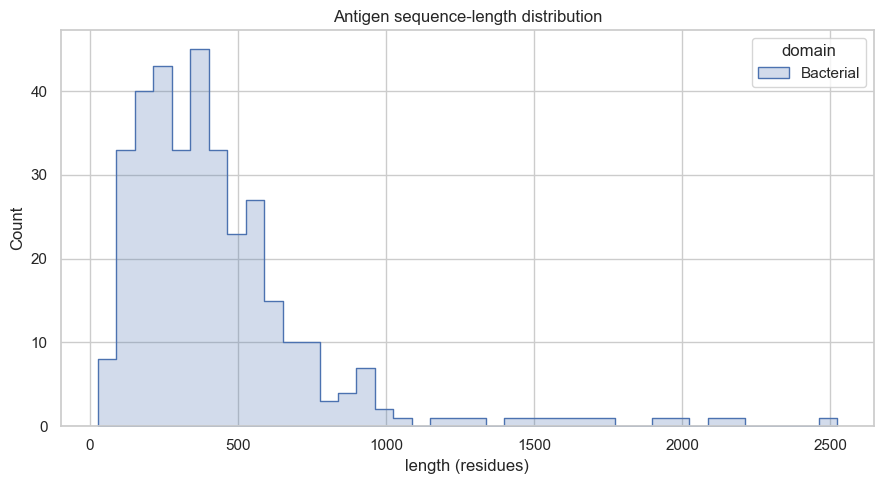

In [5]:
print(antigens.groupby("organism")["length"].describe()[["count", "mean", "50%", "min", "max"]].round(0).to_string())

plt.figure(figsize=(9, 5))
sns.histplot(data=antigens, x="length", hue="domain", bins=40, element="step")
plt.title("Antigen sequence-length distribution")
plt.xlabel("length (residues)")
plt.tight_layout()
plt.show()


          count   mean    50%    min     max
organism                                    
ESKAPE     64.0  458.0  391.0   46.0  1627.0
GAST       37.0  373.0  363.0  110.0   752.0
INTRA      58.0  417.0  324.0  108.0  1770.0
RESP      192.0  444.0  372.0   27.0  2523.0

Sequence length by domain:
           count   mean    50%   min     max
domain                                      
Bacterial  351.0  435.0  369.0  27.0  2523.0


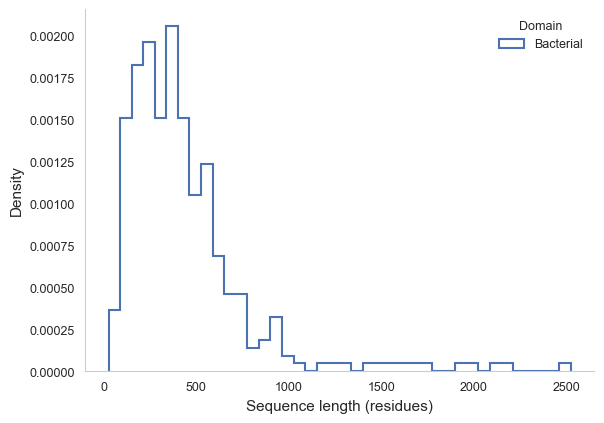

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Supplementary figure:
# Antigen sequence-length distribution
# ============================================================

FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Summary statistics
# -----------------------------
print(
    antigens.groupby("organism")["length"]
    .describe()[["count", "mean", "50%", "min", "max"]]
    .round(0)
    .to_string()
)

# Optional domain-level summary
print("\nSequence length by domain:")
print(
    antigens.groupby("domain")["length"]
    .describe()[["count", "mean", "50%", "min", "max"]]
    .round(0)
    .to_string()
)

# -----------------------------
# Prepare groups
# -----------------------------
domains = [
    d for d in antigens["domain"].dropna().unique()
]

domains = sorted(domains)

# Use common bin edges for all groups
xmin = antigens["length"].min()
xmax = antigens["length"].max()

bins = np.linspace(
    xmin,
    xmax,
    41
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6.2, 4.4))

linestyles = ["-", "--", "-.", ":"]

for i, domain in enumerate(domains):

    vals = (
        antigens.loc[
            antigens["domain"] == domain,
            "length"
        ]
        .dropna()
        .to_numpy()
    )

    ax.hist(
        vals,
        bins=bins,
        histtype="step",
        density=True,
        linewidth=1.5,
        linestyle=linestyles[i % len(linestyles)],
        label=str(domain)
    )

# -----------------------------
# Axes
# -----------------------------
ax.set_xlabel("Sequence length (residues)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)

ax.tick_params(
    axis="both",
    labelsize=9,
    width=0.8,
    length=4
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.grid(False)

# Legend
ax.legend(
    frameon=False,
    fontsize=9,
    title="Domain",
    title_fontsize=9
)

fig.tight_layout()

# -----------------------------
# Save
# -----------------------------
fig.savefig(
    FIGURE_DIR / "supp_antigen_sequence_length_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    FIGURE_DIR / "supp_antigen_sequence_length_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

## 5. Tier 1 — epitope statistics

Prevalence (epitope fraction) sets the PR-AUC floor and is not comparable across tracks;
epitopes-per-antigen is the matched-budget N used throughout the benchmark.

residue-level epitope prevalence:
organism  residues  prev_linear  prev_conf
  ESKAPE     29319       0.1113     0.0161
    GAST     13798       0.2142     0.0108
   INTRA     24204       0.1264     0.0025
    RESP     85332       0.1336     0.0026

overall linear prevalence: 0.1354 | conformational: 0.0059

linear: epitopes/antigen  mean=8.46  median=2  max=426  |  epitope length  mean=14.5  median=15

conformational: epitopes/antigen  mean=3.89  median=2  max=29  |  epitope length  mean=8.4  median=5


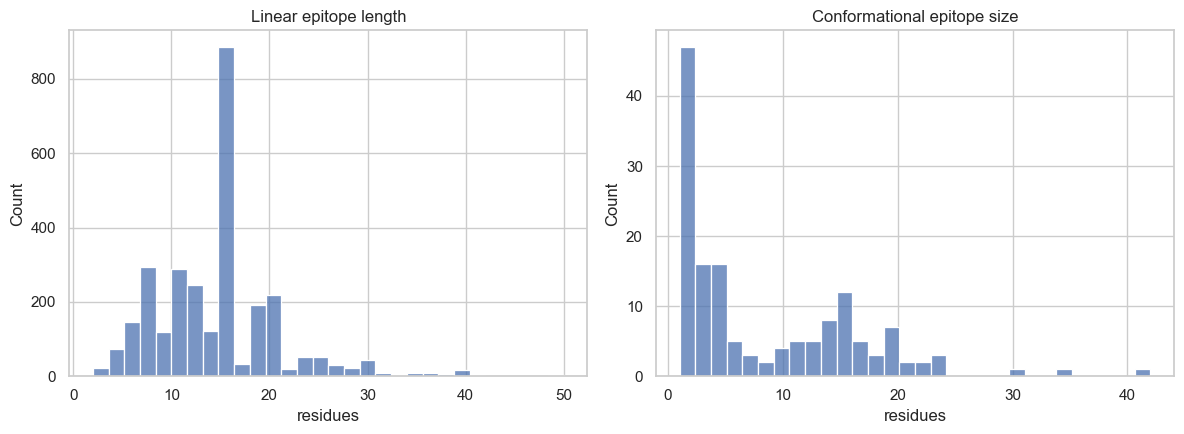

In [7]:
# residue-level prevalence per track, overall and per group
prev = residues.groupby("organism").agg(
    residues=("res_index", "size"),
    prev_linear=("epi_linear", "mean"),
    prev_conf=("epi_conf", "mean")).reset_index()
print("residue-level epitope prevalence:")
print(prev.round(4).to_string(index=False))
print("\noverall linear prevalence:", round(residues['epi_linear'].mean(), 4),
      "| conformational:", round(residues['epi_conf'].mean(), 4))

# epitopes per antigen + epitope length, per track
for name, epi in [("linear", epi_lin), ("conformational", epi_con)]:
    per_ant = epi.groupby("uniprot").size()
    print(f"\n{name}: epitopes/antigen  mean={per_ant.mean():.2f}  median={per_ant.median():.0f}  "
          f"max={per_ant.max():.0f}  |  epitope length  mean={epi['length'].mean():.1f}  "
          f"median={epi['length'].median():.0f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(epi_lin["length"], bins=30, ax=ax[0]); ax[0].set_title("Linear epitope length")
sns.histplot(epi_con["length"], bins=30, ax=ax[1]); ax[1].set_title("Conformational epitope size")
for a in ax:
    a.set_xlabel("residues")
plt.tight_layout()
plt.show()


## 6. Tier 2 — structural properties (pLDDT, and RSA if supplied)

pLDDT distribution sets up the confidence stratification (methods 4.3.6). The epitope-vs-non
contrast shows where the signal structure models key on actually sits.

mean pLDDT per antigen:
          mean   50%   min   max
organism                        
ESKAPE    85.2  88.9  53.7  98.1
GAST      85.8  90.3  40.0  97.6
INTRA     77.6  80.0  41.9  97.5
RESP      83.1  87.5  16.7  97.5


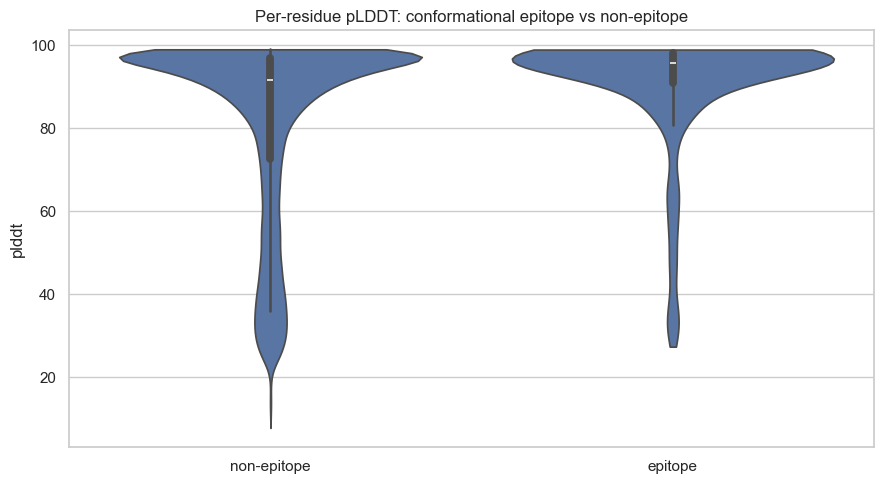

median pLDDT  epitope: 95.8  non-epitope: 91.7

[RSA skipped — set RSA_SOURCE to a uniprot,res_index,rsa CSV to enable]


In [8]:
print("mean pLDDT per antigen:")
print(antigens.groupby("organism")["mean_plddt"].describe()[["mean", "50%", "min", "max"]].round(1).to_string())

# epitope vs non-epitope pLDDT (conformational track is the structural one)
melt = residues.copy()
melt["class_conf"] = np.where(melt["epi_conf"] == 1, "epitope", "non-epitope")
plt.figure(figsize=(9, 5))
sns.violinplot(data=melt, x="class_conf", y="plddt", cut=0)
plt.title("Per-residue pLDDT: conformational epitope vs non-epitope")
plt.xlabel("")
plt.tight_layout()
plt.show()
print("median pLDDT  epitope:", round(melt.loc[melt.epi_conf == 1, 'plddt'].median(), 1),
      " non-epitope:", round(melt.loc[melt.epi_conf == 0, 'plddt'].median(), 1))

# optional RSA
if RSA_SOURCE is not None and Path(RSA_SOURCE).exists():
    rsa = pd.read_csv(RSA_SOURCE)[["uniprot", "res_index", "rsa"]]
    m = residues.merge(rsa, on=["uniprot", "res_index"], how="left")
    print("\nRSA (epitope vs non, conformational):",
          "epitope", round(m.loc[m.epi_conf == 1, 'rsa'].median(), 3),
          "| non", round(m.loc[m.epi_conf == 0, 'rsa'].median(), 3))
else:
    print("\n[RSA skipped — set RSA_SOURCE to a uniprot,res_index,rsa CSV to enable]")



Conformational epitope pLDDT summary:
              count  median  mean
class_conf                       
Non-epitope  151749    91.7  80.8
Epitope         904    95.8  90.3

Mean pLDDT per antigen:
          mean   50%   min   max
organism                        
ESKAPE    85.2  88.9  53.7  98.1
GAST      85.8  90.3  40.0  97.6
INTRA     77.6  80.0  41.9  97.5
RESP      83.1  87.5  16.7  97.5


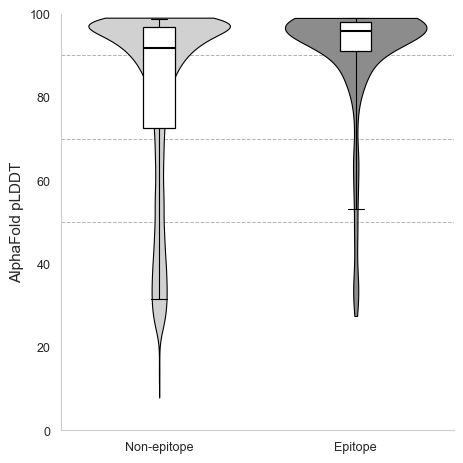


[RSA skipped — set RSA_SOURCE to a uniprot,res_index,rsa CSV to enable]


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Supplementary figure:
# AlphaFold pLDDT in conformational epitope vs non-epitope residues
# ============================================================

FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Prepare data
# -----------------------------
plot_df = residues.loc[
    residues["plddt"].notna() & residues["epi_conf"].notna(),
    ["plddt", "epi_conf"]
].copy()

plot_df["class_conf"] = np.where(
    plot_df["epi_conf"] == 1,
    "Epitope",
    "Non-epitope"
)

order = ["Non-epitope", "Epitope"]

data = [
    plot_df.loc[plot_df["class_conf"] == group, "plddt"].to_numpy()
    for group in order
]

# Summary statistics
summary = (
    plot_df.groupby("class_conf")["plddt"]
    .agg(["count", "median", "mean"])
    .reindex(order)
)

print("\nConformational epitope pLDDT summary:")
print(summary.round(1).to_string())

print("\nMean pLDDT per antigen:")
print(
    antigens.groupby("organism")["mean_plddt"]
    .describe()[["mean", "50%", "min", "max"]]
    .round(1)
    .to_string()
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4.8, 4.8))

# Violin distributions
vp = ax.violinplot(
    data,
    positions=[1, 2],
    widths=0.72,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    points=300
)

# Publication-style grayscale violins
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor("0.82" if i == 0 else "0.55")
    body.set_edgecolor("black")
    body.set_linewidth(0.8)
    body.set_alpha(1.0)

# Boxplots inside violins
bp = ax.boxplot(
    data,
    positions=[1, 2],
    widths=0.16,
    patch_artist=True,
    showfliers=False,
    whis=(5, 95),
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=0.9
    ),
    whiskerprops=dict(
        color="black",
        linewidth=0.8
    ),
    capprops=dict(
        color="black",
        linewidth=0.8
    )
)

# -----------------------------
# AlphaFold confidence references
# -----------------------------
for y in [50, 70, 90]:
    ax.axhline(
        y,
        linestyle="--",
        linewidth=0.7,
        color="0.70",
        zorder=0
    )

# -----------------------------
# Axes
# -----------------------------
ax.set_xticks([1, 2])
ax.set_xticklabels(order, fontsize=10)

ax.set_ylabel("AlphaFold pLDDT", fontsize=11)
ax.set_xlabel("")

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))

ax.tick_params(
    axis="both",
    labelsize=9,
    width=0.8,
    length=4
)

# Clean publication style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.grid(False)

fig.tight_layout()

# -----------------------------
# Save
# -----------------------------
fig.savefig(
    FIGURE_DIR / "supp_plddt_epitope_vs_nonepitope.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    FIGURE_DIR / "supp_plddt_epitope_vs_nonepitope.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Optional RSA summary
# ============================================================

if RSA_SOURCE is not None and Path(RSA_SOURCE).exists():

    rsa = pd.read_csv(RSA_SOURCE)[
        ["uniprot", "res_index", "rsa"]
    ]

    m = residues.merge(
        rsa,
        on=["uniprot", "res_index"],
        how="left"
    )

    print(
        "\nRSA (conformational epitope vs non-epitope):",
        "epitope =",
        round(
            m.loc[m["epi_conf"] == 1, "rsa"].median(),
            3
        ),
        "| non-epitope =",
        round(
            m.loc[m["epi_conf"] == 0, "rsa"].median(),
            3
        )
    )

else:
    print(
        "\n[RSA skipped — set RSA_SOURCE to a "
        "uniprot,res_index,rsa CSV to enable]"
    )

## 7. Tier 3 — redundancy (alignment-free)

Exact duplicates plus k-mer Jaccard similarity between antigens. This *characterises* redundancy
without any external tool; for a citable identity-clustering threshold, ingest MMseqs2 below.

exact duplicate sequences: 1
near-duplicate pairs (k-mer Jaccard >= 0.9): 1
antigens with a near-duplicate: 2 / 351


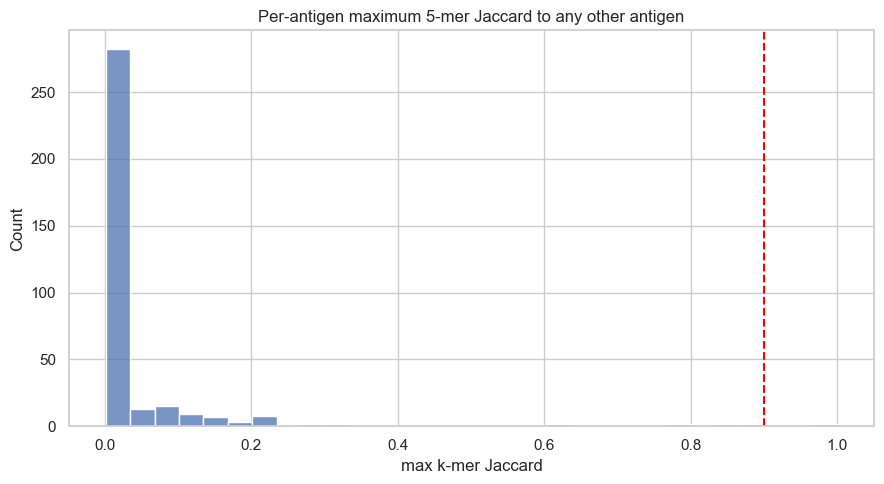

In [10]:
def kmer_set(seq, k):
    return {seq[i:i + k] for i in range(len(seq) - k + 1)} if len(seq) >= k else {seq}

seqs = antigens["sequence"].tolist()
ksets = [kmer_set(s, KMER_K) for s in seqs]
n = len(ksets)

exact_dupes = int(antigens["sequence"].duplicated().sum())
maxsim = np.zeros(n)
near_pairs = 0
for i in range(n):
    for j in range(i + 1, n):
        inter = len(ksets[i] & ksets[j])
        if inter == 0:
            continue
        jac = inter / len(ksets[i] | ksets[j])
        if jac > maxsim[i]: maxsim[i] = jac
        if jac > maxsim[j]: maxsim[j] = jac
        if jac >= NEAR_DUP_THRESHOLD:
            near_pairs += 1
antigens["max_kmer_jaccard"] = maxsim

print(f"exact duplicate sequences: {exact_dupes}")
print(f"near-duplicate pairs (k-mer Jaccard >= {NEAR_DUP_THRESHOLD}): {near_pairs}")
print(f"antigens with a near-duplicate: {(maxsim >= NEAR_DUP_THRESHOLD).sum()} / {n}")

plt.figure(figsize=(9, 5))
sns.histplot(maxsim, bins=30)
plt.axvline(NEAR_DUP_THRESHOLD, ls="--", color="red")
plt.title(f"Per-antigen maximum {KMER_K}-mer Jaccard to any other antigen")
plt.xlabel("max k-mer Jaccard")
plt.tight_layout()
plt.show()


### 7b. Redundancy — MMseqs2 clusters (optional)

If you run `mmseqs easy-cluster antigens.fasta clusterRes tmp --min-seq-id 0.3 -c 0.8` on BlueBEAR
and point `MMSEQS_CLUSTERS` at the resulting `*_cluster.tsv`, this reports the identity-based
cluster count for the methods redundancy statement.

In [11]:
if MMSEQS_CLUSTERS is not None and Path(MMSEQS_CLUSTERS).exists():
    cl = pd.read_csv(MMSEQS_CLUSTERS, sep="\t", header=None, names=["representative", "member"])
    n_clusters = cl["representative"].nunique()
    n_members = cl["member"].nunique()
    print(f"MMseqs2 clusters: {n_clusters} from {n_members} antigens "
          f"(reduction {1 - n_clusters / n_members:.1%})")
else:
    print("[MMseqs2 skipped — set MMSEQS_CLUSTERS to an easy-cluster *_cluster.tsv to enable]")


[MMseqs2 skipped — set MMSEQS_CLUSTERS to an easy-cluster *_cluster.tsv to enable]


## 8. Tier 3 — taxonomy (optional)

In [12]:
if SPECIES_SOURCE is not None and Path(SPECIES_SOURCE).exists():
    sp = pd.read_csv(SPECIES_SOURCE)[["uniprot", "species"]]
    a = antigens.merge(sp, on="uniprot", how="left")
    print("distinct species overall:", a["species"].nunique())
    print(a.groupby("organism")["species"].nunique().rename("n_species").to_string())
else:
    print("[Taxonomy skipped — set SPECIES_SOURCE to a uniprot,species CSV to enable]")


[Taxonomy skipped — set SPECIES_SOURCE to a uniprot,species CSV to enable]


## 9. Tier 4 — train/test leakage (deferred)

A full leakage check needs each model's exact training set, which is not uniformly available.
Reportable without that: (i) a **temporal caveat** — several models (BepiPred-3.0, DiscoTope-3.0)
were trained on IEDB-derived data predating this benchmark's IEDB download, so overlap is likely
and their numbers may be optimistic; (ii) for models that publish a training-accession list
(e.g. DiscoTope-3.0), an accession-overlap check (hook below).

In [13]:
# Optional accession-overlap hook: provide a text file of training UniProt accessions.
TRAIN_ACCESSIONS = None   # e.g. "discotope3_train_accessions.txt"
if TRAIN_ACCESSIONS is not None and Path(TRAIN_ACCESSIONS).exists():
    train = {ln.strip() for ln in open(TRAIN_ACCESSIONS) if ln.strip()}
    ours = set(antigens["uniprot"])
    overlap = ours & train
    print(f"benchmark antigens overlapping training list: {len(overlap)} / {len(ours)} "
          f"({len(overlap) / len(ours):.1%})")
else:
    print("[Leakage: deferred. Report the temporal caveat in the discussion; set TRAIN_ACCESSIONS "
          "to a model's training-accession list to compute overlap.]")


[Leakage: deferred. Report the temporal caveat in the discussion; set TRAIN_ACCESSIONS to a model's training-accession list to compute overlap.]


## 10. Summary table & reporting notes

In [14]:
summary = (antigens.groupby("organism")
           .agg(n_antigens=("uniprot", "nunique"),
                median_length=("length", "median"),
                median_plddt=("mean_plddt", "median"),
                pct_near_dup=("max_kmer_jaccard", lambda s: (s >= NEAR_DUP_THRESHOLD).mean())))
prev_g = residues.groupby("organism").agg(prev_linear=("epi_linear", "mean"),
                                          prev_conf=("epi_conf", "mean"))
summary = summary.join(prev_g).reset_index()
print("DATASET CHARACTERISATION SUMMARY")
print(summary.round(3).to_string(index=False))


DATASET CHARACTERISATION SUMMARY
organism  n_antigens  median_length  median_plddt  pct_near_dup  prev_linear  prev_conf
  ESKAPE          64          391.0        88.852          0.00        0.111      0.016
    GAST          37          363.0        90.289          0.00        0.214      0.011
   INTRA          58          324.5        80.034          0.00        0.126      0.003
    RESP         192          372.0        87.474          0.01        0.134      0.003


**Feeds the methods:**

- Tier 3 redundancy → the 4.1.1 redundancy-reduction placeholder (report the alignment-free numbers,
  or the MMseqs2 cluster count if run).
- Tier 2 pLDDT → the 4.3.6 pLDDT stratification (use the pLDDT distribution to choose bins).
- Tier 1 prevalence and epitopes-per-antigen contextualise the PR-AUC floors and the matched-budget N.

**Watch for confounds:** if groups differ systematically in length, prevalence, or pLDDT, any
per-group performance gap may be a dataset artefact rather than a model difference — stratify or
state it. **Extensibility:** add viral groups by extending `ORGS`/`DOMAIN`; everything recomputes.

Antigen sequence length:
count     351.0
mean      435.0
50%       369.0
min        27.0
max      2523.0

Conformational epitope pLDDT:
                 count  mean  median
class_conf                          
Other residues  151749  80.8    91.7
Epitope            904  90.3    95.8


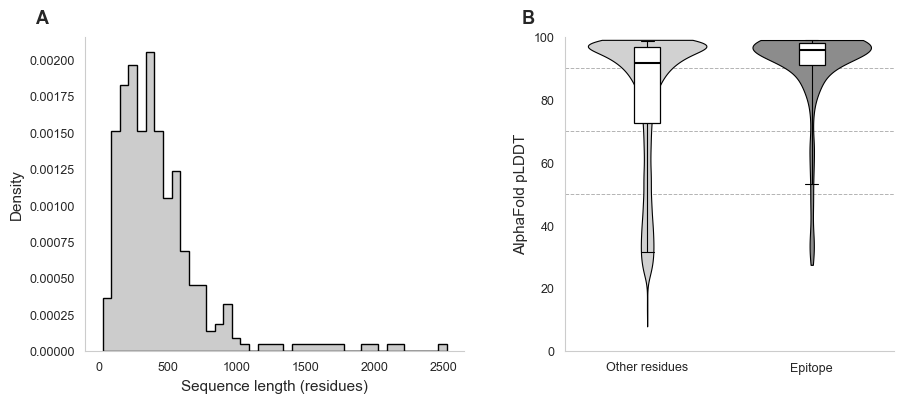

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Supplementary figure:
# Antigen sequence length and AlphaFold structural confidence
# ============================================================

FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Prepare data
# ============================================================

# ---------- Panel A: antigen sequence length ----------
lengths = antigens["length"].dropna().to_numpy()

print("Antigen sequence length:")
print(
    antigens["length"]
    .describe()[["count", "mean", "50%", "min", "max"]]
    .round(0)
    .to_string()
)

# Common 40-bin representation
bins = np.linspace(
    lengths.min(),
    lengths.max(),
    41
)


# ---------- Panel B: conformational epitope pLDDT ----------
plddt_df = residues.loc[
    residues["plddt"].notna() & residues["epi_conf"].notna(),
    ["plddt", "epi_conf"]
].copy()

plddt_df["class_conf"] = np.where(
    plddt_df["epi_conf"] == 1,
    "Epitope",
    "Other residues"
)

order = ["Other residues", "Epitope"]

violin_data = [
    plddt_df.loc[
        plddt_df["class_conf"] == group,
        "plddt"
    ].to_numpy()
    for group in order
]

print("\nConformational epitope pLDDT:")
print(
    plddt_df.groupby("class_conf")["plddt"]
    .agg(["count", "mean", "median"])
    .reindex(order)
    .round(1)
    .to_string()
)


# ============================================================
# Figure
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.2, 4.2),
    gridspec_kw={"width_ratios": [1.15, 1]}
)

ax1, ax2 = axes


# ============================================================
# Panel A — antigen sequence-length distribution
# ============================================================

ax1.hist(
    lengths,
    bins=bins,
    density=True,
    histtype="stepfilled",
    facecolor="0.80",
    edgecolor="black",
    linewidth=1.0
)

ax1.set_xlabel("Sequence length (residues)", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)

ax1.tick_params(
    axis="both",
    labelsize=9,
    width=0.8,
    length=4
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_linewidth(0.8)
ax1.spines["bottom"].set_linewidth(0.8)

ax1.grid(False)

# Panel label
ax1.text(
    -0.13,
    1.03,
    "A",
    transform=ax1.transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom"
)


# ============================================================
# Panel B — pLDDT distribution
# ============================================================

vp = ax2.violinplot(
    violin_data,
    positions=[1, 2],
    widths=0.72,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    points=300
)

# Grayscale violins
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor("0.82" if i == 0 else "0.55")
    body.set_edgecolor("black")
    body.set_linewidth(0.8)
    body.set_alpha(1.0)

# Internal boxplots
ax2.boxplot(
    violin_data,
    positions=[1, 2],
    widths=0.16,
    patch_artist=True,
    showfliers=False,
    whis=(5, 95),
    medianprops=dict(
        color="black",
        linewidth=1.5
    ),
    boxprops=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=0.9
    ),
    whiskerprops=dict(
        color="black",
        linewidth=0.8
    ),
    capprops=dict(
        color="black",
        linewidth=0.8
    )
)

# AlphaFold confidence boundaries
for y in [50, 70, 90]:
    ax2.axhline(
        y,
        linestyle="--",
        linewidth=0.7,
        color="0.70",
        zorder=0
    )

ax2.set_xticks([1, 2])
ax2.set_xticklabels(order, fontsize=9)

ax2.set_ylabel("AlphaFold pLDDT", fontsize=11)
ax2.set_xlabel("")

ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 20))

ax2.tick_params(
    axis="both",
    labelsize=9,
    width=0.8,
    length=4
)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_linewidth(0.8)
ax2.spines["bottom"].set_linewidth(0.8)

ax2.grid(False)

# Panel label
ax2.text(
    -0.13,
    1.03,
    "B",
    transform=ax2.transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom"
)


# ============================================================
# Layout and save
# ============================================================

fig.tight_layout(w_pad=3.0)

fig.savefig(
    FIGURE_DIR / "supp_antigen_characteristics.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    FIGURE_DIR / "supp_antigen_characteristics.pdf",
    bbox_inches="tight"
)

plt.show()